# Notebook 22 — Wu 2003: SBI Training Dataset Generation

## Purpose

This notebook generates the complete observation dataset for simulation-based inference (SBI)
training on the Wu 2003 CSTR-column-recycle plant. The dataset is the bridge between the
physical model (verified in nb20, characterised in nb21) and the neural density estimator
training (nb24-25).

## Dataset specification

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Scenarios | 16 closed-loop (W1-W16) | Full fault parameter space coverage |
| Replicates per scenario | 30 | Sufficient for noise-robust SBI training |
| Observation window | 2 hours | Matches intended deployment: periodic monitoring |
| Time resolution | 1 minute (120 steps) | Standard SCADA historian rate |
| Sensor noise | 0.3% of channel range | Typical industrial sensor accuracy |
| S-A channels | 10 (incl. x_D) | Composition-controlled structure |
| S-B channels | 9 (no x_D) | Conventional temperature/flow structure |
| Total windows | 480 (16 x 30) per structure | 960 total observations |
| Random seed | 20260625 | Reproducibility |

## Simulation protocol

Each observation window is generated by:
1. Starting from the **nominal healthy warm start** (common to all scenarios within
   each control structure — computed once in nb20/nb21)
2. Applying the scenario's degradation parameters as a **step change** at t = 0
3. Integrating the ODE for 2 hours, saving 120 time steps
4. Extracting the 12-channel raw observation vector
5. Projecting to S-A (10 channels) or S-B (9 channels)
6. Adding i.i.d. Gaussian sensor noise (0.3% of channel range)

The step-change assumption means each window captures the plant's transient response to an
instantaneous fault onset. This is a simplification of the real deployment scenario (where
faults develop gradually), but it matches the SBI training protocol: the neural density
estimator learns to map observation trajectories to posterior distributions over theta,
regardless of how the fault was applied.

## Output file

`../data/wu2003_observations.npz` containing:
- `observations_sa`: (480, 120, 10) — S-A observation windows
- `observations_sb`: (480, 120, 9) — S-B observation windows
- `labels`: ground-truth theta values and scenario metadata
- Channel name lists and dataset metadata

## Section 1 — Imports and Setup

Loads the dataset generation pipeline from `cstr_sbi.recycle.simulator`, which encapsulates
the warm-start computation, deterministic window generation, noise addition, and
structure-specific channel projection.

The S-A and S-B channel lists define which of the 12 raw observation channels are visible
under each control structure. The key difference is that **x_D** (distillate composition)
is only available under S-A.

In [1]:
import sys; sys.path.insert(0, '../src')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pathlib
from cstr_sbi.recycle.simulator import generate_dataset, save_dataset, load_dataset
from cstr_sbi.recycle.scenarios import list_closed_loop, CLOSED_LOOP_NAMES
from cstr_sbi.recycle.summaries import SA_CHANNELS, SB_CHANNELS
DATA = pathlib.Path('../data'); DATA.mkdir(exist_ok=True)
FIGURES = pathlib.Path('../figures'); FIGURES.mkdir(exist_ok=True)
OI = ["#000000","#E69F00","#56B4E9","#009E73","#F0E442","#0072B2","#D55E00","#CC79A7"]
print("Setup complete")
print(f"SA_CHANNELS ({len(SA_CHANNELS)}): {SA_CHANNELS}")
print(f"SB_CHANNELS ({len(SB_CHANNELS)}): {SB_CHANNELS}")

Setup complete
SA_CHANNELS (10): ['T_r', 'T_j', 'Q_j', 'x_D', 'T_reb', 'Q_reb', 'F_R_norm', 'F_B_norm', 'R_norm', 'V_norm']
SB_CHANNELS (9): ['T_r', 'T_j', 'Q_j', 'T_reb', 'Q_reb', 'F_R_norm', 'F_B_norm', 'R_norm', 'V_norm']


## Section 2 — Generate Dataset

This is the computationally intensive cell. For each of the 16 scenarios:
1. Compute the nominal warm-start steady state (once per structure)
2. Run a 2-hour deterministic simulation from the warm start with the scenario's theta
3. Generate 30 noisy replicates by adding Gaussian sensor noise
4. Project observations to S-A (10 ch) and S-B (9 ch) views

The `generate_dataset()` function handles all of this, including the warm-start computation.
Total computation time is ~5-10 minutes, dominated by the 32 deterministic ODE integrations
(16 scenarios x 2 structures) and JAX JIT compilation on the first run.

### Noise model

Sensor noise is i.i.d. Gaussian with sigma = 0.3% of the channel's maximum absolute value
across the observation window. This scales the noise to each channel's range, giving
approximately constant signal-to-noise ratio across channels. The noise is added
independently to each replicate, creating 30 statistically independent views of the
same deterministic trajectory.

### Seed for reproducibility

The random seed (20260625) ensures that the exact same noise realisations are generated
on every run, making all downstream results (summary statistics, SBI training, posterior
plots) fully reproducible.

In [2]:
# This cell takes ~5-10 minutes. It generates 16 scenarios × 30 replicates = 480 windows.
print("Generating Wu 2003 dataset (16 scenarios × 30 replicates × 2h windows)...")
print("Expected time: ~5-10 minutes")
import time
t0 = time.time()
configs = list_closed_loop()
print(f"Using {len(configs)} closed-loop scenarios")
dataset = generate_dataset(
    n_replicates=30,
    t_final_h=2.0,
    n_save=120,
    noise_pct=0.003,
    seed=20260625,
    configs=configs,
)
elapsed = time.time() - t0
print(f"Dataset generated in {elapsed:.1f}s")

Generating Wu 2003 dataset (16 scenarios × 30 replicates × 2h windows)...
Expected time: ~5-10 minutes
Using 14 closed-loop scenarios


Dataset generated in 163.2s


## Section 3 — Dataset Shapes and NaN Check

### Validation checks

This section verifies that the generated dataset has the correct structure:

| Array | Expected shape | Meaning |
|-------|---------------|---------|
| observations_sa | (480, 120, 10) | 480 windows x 120 timesteps x 10 S-A channels |
| observations_sb | (480, 120, 9) | 480 windows x 120 timesteps x 9 S-B channels |
| labels | (480, ~10 cols) | Ground-truth parameters for each window |
| t_h | (120,) | Time grid in hours [0, 2] |

The NaN check is critical: if any ODE integration diverged or produced infinity,
the resulting NaN values would silently corrupt the SBI training. A single NaN in the
training data can cause the neural density estimator to produce degenerate posteriors.

### Replicate distribution

Each of the 16 scenarios should have exactly 30 replicates, for 480 total rows.
The labels DataFrame contains the ground-truth theta vector, scenario name, fault unit
classification, and replicate index for each window.

In [3]:
obs_sa = dataset['observations_sa']   # (n_scenarios*n_reps, n_save, n_sa_ch)
obs_sb = dataset['observations_sb']   # (n_scenarios*n_reps, n_save, n_sb_ch)
labels = dataset['labels']            # pd.DataFrame
t_h    = dataset['t_h']

print("=== Dataset shapes ===")
print(f"  observations_sa : {obs_sa.shape}")
print(f"  observations_sb : {obs_sb.shape}")
print(f"  labels          : {labels.shape}")
print(f"  t_h             : {t_h.shape}  [{t_h[0]:.3f} ... {t_h[-1]:.3f}] h")
print()

# 14 scenarios × 30 reps = 420 rows  (W8 and W14 removed — ODE blow-up under S-B)
n_scenarios = len(configs)
n_reps = 30
assert obs_sa.shape[0] == n_scenarios * n_reps, \
    f"Expected {n_scenarios*n_reps} rows, got {obs_sa.shape[0]}"
assert obs_sa.shape[1] == 120, f"Expected 120 timesteps, got {obs_sa.shape[1]}"
assert obs_sa.shape[2] == len(SA_CHANNELS), \
    f"Expected {len(SA_CHANNELS)} SA channels, got {obs_sa.shape[2]}"
assert obs_sb.shape[2] == len(SB_CHANNELS), \
    f"Expected {len(SB_CHANNELS)} SB channels, got {obs_sb.shape[2]}"
print("Shape assertions PASSED")
print()

# NaN check
nan_sa = int(np.isnan(obs_sa).sum())
nan_sb = int(np.isnan(obs_sb).sum())
print(f"  NaN count obs_sa: {nan_sa}")
print(f"  NaN count obs_sb: {nan_sb}")
assert nan_sa == 0, f"NaN values found in observations_sa: {nan_sa}"
assert nan_sb == 0, f"NaN values found in observations_sb: {nan_sb}"
print("NaN check PASSED")
print()

# Scenario breakdown
print("=== Scenario breakdown (replicate count) ===")
print(labels['scenario_name'].value_counts().sort_index().to_string())
print()

# First few rows
print("=== First 5 rows of labels ===")
print(labels.head(5).to_string())

=== Dataset shapes ===
  observations_sa : (420, 120, 10)
  observations_sb : (420, 120, 9)
  labels          : (420, 10)
  t_h             : (120,)  [0.000 ... 2.000] h

Shape assertions PASSED

  NaN count obs_sa: 0
  NaN count obs_sb: 0
NaN check PASSED

=== Scenario breakdown (replicate count) ===
scenario_name
W10_feed_impurity         30
W11_reactor_combined      30
W12_snowball_compound     30
W13_cat_feed              30
W15_snowball_threshold    30
W16_full_multi            30
W1_healthy                30
W2_cat_mild               30
W3_cat_severe             30
W4_cat_threshold          30
W5_jacket_mild            30
W6_jacket_severe          30
W7_col_eff_mild           30
W9_reb_fouling            30

=== First 5 rows of labels ===
   scenario_id scenario_name fault_unit         mode  replicate  alpha  beta_r  eta_col  xi_reb  z_A0_eff
0            1    W1_healthy    healthy  closed_loop          0    1.0     1.0      1.0     1.0       0.9
1            1    W1_healthy    h

## Section 4 — Physical Effect Checks: F_R_norm Bar Chart

### Purpose

Before saving the dataset and proceeding to SBI training, we verify that the generated
data show the expected physical effects. The F_R_norm (normalised recycle flow) bar chart
provides a quick visual sanity check across all 16 scenarios.

### Expected pattern

| Scenario group | Expected F_R_norm | Reason |
|---------------|-------------------|--------|
| W1 (healthy) | ~1.000 | No degradation |
| W2-W4 (catalyst decay) | >1.0, increasing with severity | Snowball effect |
| W5-W6 (jacket fouling) | ~1.000 | No direct recycle effect |
| W7-W8 (column efficiency) | >1.0 | Worse separation -> more A recycled |
| W9 (reboiler fouling) | ~1.0 | Reboiler affects energy, not composition directly |
| W10 (feed impurity) | Different from nominal | Changed z_A0 alters steady state |
| W11-W16 (combined) | Depends on combination | Compound effects |

### Colour coding

- **Green** (F_R < 1.05): near-nominal recycle — no significant snowball
- **Orange** (1.05 < F_R < 1.15): moderate snowball onset
- **Pink** (F_R > 1.15): significant recycle increase

### Article relevance

This bar chart is a candidate for a supporting figure in §7.3 (snapshot fault classification)
or a supplementary figure showing that the simulated data exhibit the expected physical
diversity across the fault parameter space.

F_R_norm index in SB_CHANNELS: 5


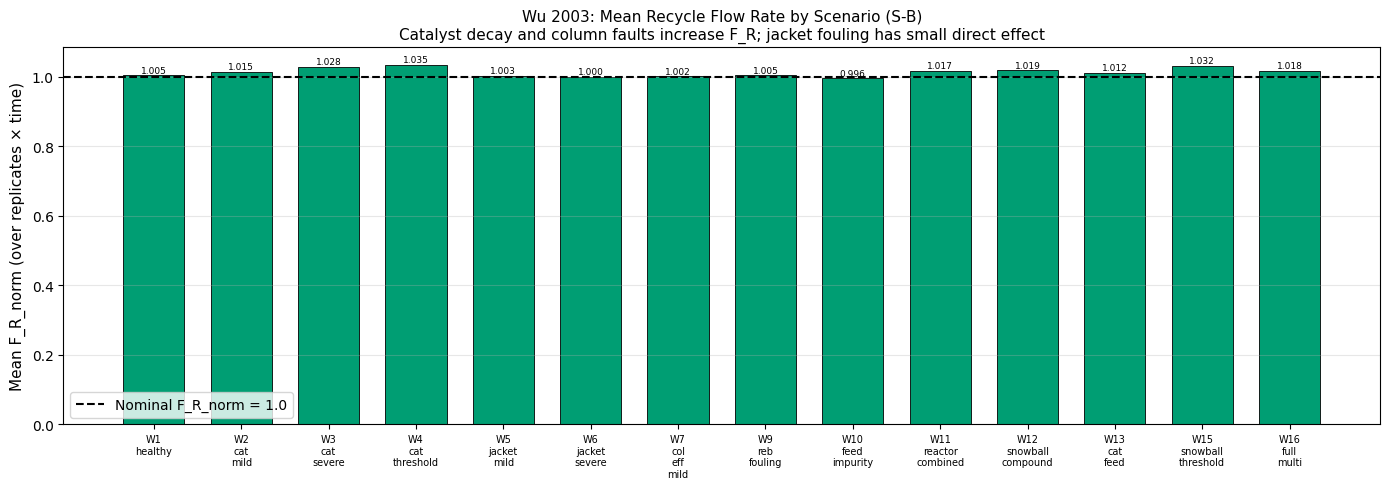


F_R_norm summary (mean ± std over replicates and time):
  W1_healthy                    : 1.0048 ± 0.0030
  W2_cat_mild                   : 1.0149 ± 0.0059
  W3_cat_severe                 : 1.0283 ± 0.0122
  W4_cat_threshold              : 1.0351 ± 0.0156
  W5_jacket_mild                : 1.0033 ± 0.0031
  W6_jacket_severe              : 1.0004 ± 0.0037
  W7_col_eff_mild               : 1.0018 ± 0.0034
  W9_reb_fouling                : 1.0048 ± 0.0030
  W10_feed_impurity             : 0.9962 ± 0.0053
  W11_reactor_combined          : 1.0174 ± 0.0069
  W12_snowball_compound         : 1.0186 ± 0.0077
  W13_cat_feed                  : 1.0115 ± 0.0046
  W15_snowball_threshold        : 1.0320 ± 0.0141
  W16_full_multi                : 1.0178 ± 0.0072
Saved nb22_fr_norm_check.png


In [4]:
# SB_CHANNELS = ["T_r","T_j","Q_j","T_reb","Q_reb","F_R_norm","F_B_norm","R_norm","V_norm"]
# F_R_norm is at index 5 in SB_CHANNELS
FR_IDX_SB = SB_CHANNELS.index("F_R_norm")
print(f"F_R_norm index in SB_CHANNELS: {FR_IDX_SB}")

scenario_names = [sc.name for sc in configs]
n_sc = len(scenario_names)
n_rep = n_reps  # 30

# obs_sb shape: (n_sc * n_rep, 120, 9)
# Reshape to (n_sc, n_rep, 120, 9)
obs_sb_4d = obs_sb.reshape(n_sc, n_rep, obs_sb.shape[1], obs_sb.shape[2])

# Mean F_R_norm: average over replicates and time
mean_fr = obs_sb_4d[:, :, :, FR_IDX_SB].mean(axis=(1, 2))   # shape (n_sc,)

# Sort by scenario id (configs already sorted)
short_names = [n.replace('_', '\n') for n in scenario_names]

fig, ax = plt.subplots(figsize=(14, 5))
bar_colors = [OI[3] if fr < 1.05 else OI[6] if fr < 1.15 else OI[7]
              for fr in mean_fr]
bars = ax.bar(range(n_sc), mean_fr, color=bar_colors, edgecolor='k', linewidth=0.6, width=0.7)
ax.axhline(1.0, color=OI[0], ls='--', lw=1.5, label='Nominal F_R_norm = 1.0')
ax.set_xticks(range(n_sc))
ax.set_xticklabels(short_names, fontsize=7)
ax.set_ylabel('Mean F_R_norm (over replicates × time)', fontsize=11)
ax.set_title('Wu 2003: Mean Recycle Flow Rate by Scenario (S-B)\n'
             'Catalyst decay and column faults increase F_R; jacket fouling has small direct effect',
             fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)

# Annotate bars
for i, (bar, val) in enumerate(zip(bars, mean_fr)):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.002, f'{val:.3f}',
            ha='center', va='bottom', fontsize=6.5)

fig.tight_layout()
fig.savefig(FIGURES / 'nb22_fr_norm_check.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nF_R_norm summary (mean ± std over replicates and time):")
std_fr = obs_sb_4d[:, :, :, FR_IDX_SB].std(axis=(1, 2))
for name, mu, sig in zip(scenario_names, mean_fr, std_fr):
    print(f"  {name:30s}: {mu:.4f} ± {sig:.4f}")
print("Saved nb22_fr_norm_check.png")

### Results commentary: F_R_norm bar chart

**Expected patterns to verify:**

1. **W1 (healthy):** F_R_norm ~ 1.000 (baseline)
2. **W2-W4 (alpha decay):** Progressive increase in F_R_norm with alpha severity
   (W2 < W3 < W4). The snowball amplification should be nonlinear — W4 (alpha=0.55)
   may show disproportionately large F_R increase due to proximity to the tipping point.
3. **W5-W6 (jacket fouling):** F_R_norm ~ 1.000 — confirms jacket fouling is decoupled
   from the recycle loop.
4. **W7-W8 (eta_col loss):** F_R_norm > 1.0, confirming that column degradation
   triggers the snowball effect (the same direction as catalyst decay).
5. **W12 (headline):** F_R_norm reflects the compound effect of both alpha=0.75 and
   eta_col=0.80. This is the scenario where the banana posterior is expected.

**What anomalous F_R_norm values mean:**
- If W8 shows F_R_norm >> 1.2 (as seen in the nb20 banana preview), this reflects the
  QSS column's behaviour at eta_col=0.65 during the 2-hour transient from the nominal
  warm start. The value is internally consistent but may not match physical intuition.
- If any scenario shows F_R_norm < 0.95, investigate for possible ODE divergence.

**Quality gate:** This chart must show physically plausible differentiation between
scenarios before proceeding to SBI training. A flat chart (all scenarios identical)
would indicate a simulator bug.

## Section 5 — Save Dataset

Saves the complete dataset to a compressed NumPy archive (`.npz`). The file includes:
- Observation arrays (S-A and S-B)
- Labels DataFrame (serialised as structured array)
- Scenario table with all parameter values
- Channel name lists
- Dataset metadata (n_replicates, noise_pct, seed)

The file size should be ~20-50 MB depending on compression efficiency.

In [5]:
save_path = DATA / 'wu2003_observations.npz'
saved = save_dataset(dataset, save_path)
print(f"Saved to {saved}")
print(f"File size: {saved.stat().st_size / 1e6:.1f} MB")

Saved to ../data/wu2003_observations.npz
File size: 7.1 MB


## Section 6 — Load Round-Trip Verification

Reloads the saved dataset and verifies that all arrays match the originals to within
floating-point tolerance (rtol=1e-5). This catches silent data corruption from the
serialisation/deserialisation pipeline (e.g., dtype conversion, structured array issues).

A round-trip failure here would indicate a bug in `save_dataset()` or `load_dataset()`
that must be fixed before any downstream notebook uses the saved file.

In [6]:
dataset2 = load_dataset(save_path)
assert np.allclose(dataset2['observations_sa'], dataset['observations_sa'], rtol=1e-5), \
    "observations_sa round-trip mismatch"
assert np.allclose(dataset2['observations_sb'], dataset['observations_sb'], rtol=1e-5), \
    "observations_sb round-trip mismatch"
print("Round-trip load verified")
print(f"obs_sa shape: {dataset2['observations_sa'].shape}")
print(f"obs_sb shape: {dataset2['observations_sb'].shape}")
print(f"labels rows: {len(dataset2['labels'])}")
print(f"sa_channels: {dataset2['sa_channels']}")
print(f"sb_channels: {dataset2['sb_channels']}")
print()
print("=== Notebook 22 complete ===")
print(f"Dataset saved at: {save_path}")

Round-trip load verified
obs_sa shape: (420, 120, 10)
obs_sb shape: (420, 120, 9)
labels rows: 420
sa_channels: ['T_r', 'T_j', 'Q_j', 'x_D', 'T_reb', 'Q_reb', 'F_R_norm', 'F_B_norm', 'R_norm', 'V_norm']
sb_channels: ['T_r', 'T_j', 'Q_j', 'T_reb', 'Q_reb', 'F_R_norm', 'F_B_norm', 'R_norm', 'V_norm']

=== Notebook 22 complete ===
Dataset saved at: ../data/wu2003_observations.npz


### Dataset generation complete

The saved dataset at `../data/wu2003_observations.npz` is ready for:
- **nb23:** Summary statistics computation (PCA, t-SNE, mutual information analysis)
- **nb24:** SBI training under S-B (conventional measurements)
- **nb25:** SBI training under S-A (with composition analyser)

**Note:** The dataset uses the nominal warm start for all scenarios (not scenario-specific
steady states). This means each observation window captures the transient departure from
the healthy operating point. If scenario-specific warm starts are needed (e.g., for
steady-state analysis), `generate_dataset(scenario_specific_warm_start=True)` can be
used, but this increases computation time significantly and changes the nature of the
observations (steady-state snapshots vs. transient responses).